# 07 — Temporal Aggregation: Closing the Gap to Darlami 2026

**Goal.** Test whether aggregating features across the 25 windows of a 1-second snapshot — rather than classifying each window independently — recovers some of the headroom between the per-window LOBO results from notebook 05 (RF MCC ≈ 0.12, CNN MCC ≈ 0.08) and the published Fed-TGCN benchmark of MCC = 0.636.

The hypothesis follows directly from the corpus literature: the bearing-prognostics signal lives in the **progression** of the spectrum across windows, not in any single 40 ms slice. Per-window classifiers throw away this temporal structure. Three plausible strategies to recover it:

1. **Classical statistical aggregation.** Collapse the 25 windows into 12 summary features = mean + standard deviation of the six per-window features. Run Random Forest as before. ~38k rows instead of 946k.
2. **LSTM over the 25-window sequence.** Each (file × bearing) is a `(25, 6)` matrix; an LSTM consumes it left-to-right and emits a final hidden state that feeds a softmax classifier.
3. **Graph + temporal (Darlami Fed-TGCN).** Out of scope for this notebook — it is what the corpus literature ceiling looks like.

I test strategies 1 and 2 here under the same 12-fold LOBO protocol as notebook 05 for direct comparison.

In [1]:
from __future__ import annotations

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import matthews_corrcoef, f1_score, average_precision_score
from sklearn.preprocessing import label_binarize

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

DEVICE = torch.device("mps") if torch.backends.mps.is_available() else (
    torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
)
print(f"PyTorch {torch.__version__} | device: {DEVICE}")
torch.manual_seed(42)
np.random.seed(42)

NB_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
PROJECT_ROOT = NB_DIR.parent
FIG_DIR = PROJECT_ROOT / "figures"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR.mkdir(exist_ok=True)

PyTorch 2.10.0.dev20251110 | device: mps


## 1. Load the per-window feature matrix and aggregate to per (file × bearing)

In [2]:
features_df = pd.read_parquet(PROCESSED_DIR / "all_sets_features.parquet")
FEATURE_COLS = ["env_rms", "kurtosis", "log_e_bpfo", "log_e_hf", "log_e_bpfi"]   # drop raw_rms

# Aggregate the 25 windows per (file × bearing) into mean + std features
agg_specs = {col: ["mean", "std"] for col in FEATURE_COLS}
agg = features_df.groupby(["set", "file", "bearing", "bearing_uid"]).agg(agg_specs)
agg.columns = [f"{stat}_{feat}" for feat, stat in agg.columns]
agg = agg.reset_index()
# attach per-file state (same for all windows of a file × bearing)
state = features_df.groupby(["file", "bearing"])["state"].first().reset_index()
agg = agg.merge(state, on=["file", "bearing"])
print(f"Aggregated matrix: {agg.shape}  (expected ~37,856 file×bearing samples)")
print(agg.head())

Aggregated matrix: (37856, 15)  (expected ~37,856 file×bearing samples)
   set                 file  bearing  bearing_uid  mean_env_rms  std_env_rms  \
0    1  2003.10.22.12.06.24        1           11      0.148318     0.010825   
1    1  2003.10.22.12.06.24        2           12      0.158580     0.007924   
2    1  2003.10.22.12.06.24        3           13      0.158007     0.006558   
3    1  2003.10.22.12.06.24        4           14      0.124156     0.005342   
4    1  2003.10.22.12.09.13        1           11      0.146812     0.011142   

   mean_kurtosis  std_kurtosis  mean_log_e_bpfo  std_log_e_bpfo  \
0       3.718788      1.161949         1.780666        0.679216   
1       3.116354      0.531776         2.400821        0.595167   
2       3.328176      0.290305         2.258152        0.704991   
3       3.570065      0.454375         1.462573        0.452568   
4       3.609298      0.797898         1.656465        0.645330   

   mean_log_e_hf  std_log_e_hf  mean_log_e_b

## 2. Tensor-of-sequences for the LSTM

For strategy 2, each (file × bearing) becomes a `(25, 6)` matrix of consecutive 40 ms feature vectors. Stack them into a `(n_groups, 25, 6)` tensor.

In [3]:
# Sort feature matrix by (file, bearing, window_idx) so groupby preserves window order
features_df = features_df.sort_values(["file", "bearing", "window_idx"]).reset_index(drop=True)

seq_groups = features_df.groupby(["file", "bearing"], sort=False)
n_groups = len(seq_groups)
SEQ_LEN = 25
SEQ_X = np.empty((n_groups, SEQ_LEN, len(FEATURE_COLS)), dtype=np.float32)
SEQ_y = np.empty(n_groups, dtype=np.int64)
SEQ_uid = np.empty(n_groups, dtype=np.int8)

for i, ((fname, bearing), grp) in enumerate(seq_groups):
    assert len(grp) == SEQ_LEN
    SEQ_X[i] = grp[FEATURE_COLS].to_numpy()
    SEQ_y[i] = grp["state"].iloc[0]
    SEQ_uid[i] = grp["bearing_uid"].iloc[0]

# Quick sanity: rows should match the agg dataframe in the same order
print(f"sequence tensor: {SEQ_X.shape}  labels {SEQ_y.shape}  uids {SEQ_uid.shape}")
print(f"label distribution: {dict(zip(*np.unique(SEQ_y, return_counts=True)))}")

sequence tensor: (37856, 25, 5)  labels (37856,)  uids (37856,)
label distribution: {np.int64(0): np.int64(35871), np.int64(1): np.int64(659), np.int64(2): np.int64(1326)}


## 3. LOBO splitter — same 12 bearings as notebook 05

In [4]:
BEARING_UIDS = sorted(np.unique(SEQ_uid).tolist())
NAMES = {13: "S1 B3 inner-race", 14: "S1 B4 ball-element",
         21: "S2 B1 outer-race", 33: "S3 B3 outer-race"}


def evaluate_fold(y_true, pred, proba=None):
    mcc = matthews_corrcoef(y_true, pred)
    f1m = f1_score(y_true, pred, average="macro", zero_division=0)
    aps = {"AP_Normal": float("nan"), "AP_Degraded": float("nan"), "AP_Critical": float("nan")}
    if proba is not None and len(np.unique(y_true)) > 1:
        y_bin = label_binarize(y_true, classes=[0, 1, 2])
        for cls_idx, key in enumerate(["AP_Normal", "AP_Degraded", "AP_Critical"]):
            try:
                if y_bin[:, cls_idx].sum() > 0:
                    aps[key] = average_precision_score(y_bin[:, cls_idx], proba[:, cls_idx])
            except (ValueError, IndexError):
                pass
    return {"MCC": mcc, "F1_macro": f1m, **aps}

## 4. Strategy 1 — Random Forest on aggregated 12-D features

In [5]:
agg_feature_cols = [c for c in agg.columns if c.startswith(("mean_", "std_"))]
print(f"Aggregated features ({len(agg_feature_cols)}): {agg_feature_cols}")

rf_agg_results = []
t0 = time.time()
for fold, test_uid in enumerate(BEARING_UIDS):
    test_mask = agg["bearing_uid"] == test_uid
    X_train = agg.loc[~test_mask, agg_feature_cols].to_numpy()
    y_train = agg.loc[~test_mask, "state"].to_numpy()
    X_test  = agg.loc[test_mask, agg_feature_cols].to_numpy()
    y_test  = agg.loc[test_mask, "state"].to_numpy()

    rf = RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_leaf=2,
        class_weight="balanced", n_jobs=-1, random_state=42,
    )
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    proba = rf.predict_proba(X_test)
    if proba.shape[1] < 3:
        full = np.zeros((proba.shape[0], 3))
        for j, cls in enumerate(rf.classes_):
            full[:, cls] = proba[:, j]
        proba = full

    m = evaluate_fold(y_test, pred, proba)
    m.update({"fold": fold, "test_uid": int(test_uid),
              "fault_mode": NAMES.get(int(test_uid), "Normal")})
    rf_agg_results.append(m)
    print(f"  fold {fold+1:2d}/12 | {NAMES.get(int(test_uid), 'Normal'):<22s} | "
          f"MCC={m['MCC']:+.3f}  F1m={m['F1_macro']:.3f}  AP_Cr={m['AP_Critical']:.3f}")

rf_agg_df = pd.DataFrame(rf_agg_results)
print(f"\nRF (aggregated stats) LOBO mean ± std: MCC = {rf_agg_df['MCC'].mean():+.3f} ± {rf_agg_df['MCC'].std():.3f}")
print(f"  failure-folds-only mean MCC = {rf_agg_df[rf_agg_df['fault_mode'] != 'Normal']['MCC'].mean():+.3f}")

Aggregated features (10): ['mean_env_rms', 'std_env_rms', 'mean_kurtosis', 'std_kurtosis', 'mean_log_e_bpfo', 'std_log_e_bpfo', 'mean_log_e_hf', 'std_log_e_hf', 'mean_log_e_bpfi', 'std_log_e_bpfi']


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


  fold  1/12 | Normal                 | MCC=+0.000  F1m=1.000  AP_Cr=nan


  fold  2/12 | Normal                 | MCC=+0.000  F1m=0.500  AP_Cr=nan


  fold  3/12 | S1 B3 inner-race       | MCC=+0.429  F1m=0.387  AP_Cr=0.366


...

  fold  8/12 | Normal                 | MCC=+0.000  F1m=0.499  AP_Cr=nan


  fold  9/12 | Normal                 | MCC=+0.000  F1m=0.500  AP_Cr=nan


  fold 10/12 | Normal                 | MCC=+0.000  F1m=0.332  AP_Cr=nan


  fold 11/12 | S3 B3 outer-race       | MCC=+0.225  F1m=0.376  AP_Cr=0.729


  fold 12/12 | Normal                 | MCC=+0.000  F1m=0.499  AP_Cr=nan

RF (aggregated stats) LOBO mean ± std: MCC = +0.078 ± 0.136
  failure-folds-only mean MCC = +0.234


## 5. Strategy 2 — LSTM over the 25-window sequence

In [6]:
class BearingLSTM(nn.Module):
    def __init__(self, input_dim: int = 5, hidden_dim: int = 64, n_classes: int = 3, dropout: float = 0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, num_layers=2,
                            batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.fc2 = nn.Linear(32, n_classes)

    def forward(self, x):
        # x: (B, T=25, F=5)
        out, (h, _c) = self.lstm(x)
        last = h[-1]
        last = self.dropout(last)
        return self.fc2(F.relu(self.fc1(last)))


def predict_probs_lstm(model, X: np.ndarray, batch: int = 512) -> np.ndarray:
    model.eval()
    out = []
    with torch.no_grad():
        for s in range(0, len(X), batch):
            xb = torch.from_numpy(X[s:s + batch]).to(DEVICE)
            logits = model(xb)
            out.append(F.softmax(logits, dim=1).cpu().numpy())
    return np.concatenate(out)


def train_lstm(X_train, y_train, epochs: int = 30, batch: int = 256, lr: float = 1e-3) -> nn.Module:
    model = BearingLSTM(input_dim=X_train.shape[2], hidden_dim=64, n_classes=3).to(DEVICE)
    class_counts = np.bincount(y_train, minlength=3).clip(min=1)
    weights_t = torch.tensor(len(y_train) / (3.0 * class_counts), dtype=torch.float32, device=DEVICE)
    criterion = nn.CrossEntropyLoss(weight=weights_t)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    X_t = torch.from_numpy(X_train)
    y_t = torch.from_numpy(y_train.astype(np.int64))
    ds = TensorDataset(X_t, y_t)
    loader = DataLoader(ds, batch_size=batch, shuffle=True, num_workers=0)
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            optimiser.zero_grad()
            loss.backward()
            optimiser.step()
    return model

In [7]:
lstm_results = []
t0 = time.time()
for fold, test_uid in enumerate(BEARING_UIDS):
    test_mask = SEQ_uid == test_uid
    X_train = SEQ_X[~test_mask]
    y_train = SEQ_y[~test_mask]
    X_test  = SEQ_X[test_mask]
    y_test  = SEQ_y[test_mask]

    torch.manual_seed(42)
    model = train_lstm(X_train, y_train, epochs=20, batch=256, lr=1e-3)
    proba = predict_probs_lstm(model, X_test)
    pred = proba.argmax(axis=1)

    m = evaluate_fold(y_test, pred, proba)
    m.update({"fold": fold, "test_uid": int(test_uid),
              "fault_mode": NAMES.get(int(test_uid), "Normal")})
    lstm_results.append(m)

    elapsed = time.time() - t0
    print(f"  fold {fold+1:2d}/12 | {NAMES.get(int(test_uid), 'Normal'):<22s} | "
          f"MCC={m['MCC']:+.3f}  F1m={m['F1_macro']:.3f}  AP_Cr={m['AP_Critical']:.3f}  | "
          f"elapsed {elapsed:5.1f}s")

    del model
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

lstm_df = pd.DataFrame(lstm_results)
print(f"\nLSTM (sequence model) LOBO mean ± std: MCC = {lstm_df['MCC'].mean():+.3f} ± {lstm_df['MCC'].std():.3f}")
print(f"  failure-folds-only mean MCC = {lstm_df[lstm_df['fault_mode'] != 'Normal']['MCC'].mean():+.3f}")

  fold  1/12 | Normal                 | MCC=+0.000  F1m=0.307  AP_Cr=nan  | elapsed  92.1s


  fold  2/12 | Normal                 | MCC=+0.000  F1m=0.500  AP_Cr=nan  | elapsed 154.7s


  fold  3/12 | S1 B3 inner-race       | MCC=+0.142  F1m=0.235  AP_Cr=0.982  | elapsed 205.0s


  fold  4/12 | S1 B4 ball-element     | MCC=+0.377  F1m=0.513  AP_Cr=0.739  | elapsed 244.2s


  fold  5/12 | S2 B1 outer-race       | MCC=+0.651  F1m=0.545  AP_Cr=0.974  | elapsed 284.0s


...

  fold  8/12 | Normal                 | MCC=+0.000  F1m=0.496  AP_Cr=nan  | elapsed 411.8s


  fold  9/12 | Normal                 | MCC=+0.000  F1m=0.332  AP_Cr=nan  | elapsed 460.0s


  fold 10/12 | Normal                 | MCC=+0.000  F1m=0.317  AP_Cr=nan  | elapsed 493.0s


  fold 11/12 | S3 B3 outer-race       | MCC=+0.284  F1m=0.408  AP_Cr=0.645  | elapsed 521.8s


  fold 12/12 | Normal                 | MCC=+0.000  F1m=0.331  AP_Cr=nan  | elapsed 549.0s

LSTM (sequence model) LOBO mean ± std: MCC = +0.121 ± 0.211
  failure-folds-only mean MCC = +0.363


## 6. Summary — three rows of evidence on the same data

In [8]:
def summarise(df: pd.DataFrame, name: str) -> dict:
    failure = df[df["fault_mode"] != "Normal"]
    return {
        "model": name,
        "MCC_mean (all 12)": df["MCC"].mean(),
        "MCC_std": df["MCC"].std(),
        "MCC_failure_folds": failure["MCC"].mean(),
        "F1_macro_mean": df["F1_macro"].mean(),
        "AP_Critical_mean": df["AP_Critical"].mean(),
    }


# Pull previous results from notebook 05's numbers (these are hard-coded for cross-comparison)
summary = pd.DataFrame([
    {"model": "Random Forest, per-window (notebook 05)",
     "MCC_mean (all 12)": 0.120, "MCC_std": 0.185,
     "MCC_failure_folds": 0.357, "F1_macro_mean": 0.362, "AP_Critical_mean": 0.695},
    {"model": "1D-CNN, per-window (notebook 05)",
     "MCC_mean (all 12)": 0.075, "MCC_std": 0.135,
     "MCC_failure_folds": 0.226, "F1_macro_mean": 0.297, "AP_Critical_mean": 0.505},
    summarise(rf_agg_df, "Random Forest, aggregated stats (this notebook)"),
    summarise(lstm_df,   "LSTM, 25-window sequence (this notebook)"),
    {"model": "Darlami Fed-TGCN 2026 (literature)",
     "MCC_mean (all 12)": 0.636, "MCC_std": 0.285,
     "MCC_failure_folds": float("nan"), "F1_macro_mean": float("nan"), "AP_Critical_mean": 0.675},
]).round(3)
summary

,model,MCC_mean (all 12),MCC_std,MCC_failure_folds,F1_macro_mean,AP_Critical_mean
0,"Random Forest, per-window (notebook 05)",0.120,0.185,0.357,0.362,0.695
1,"1D-CNN, per-window (notebook 05)",0.075,0.135,0.226,0.297,0.505
2,"Random Forest, aggregated stats (this notebook)",0.078,0.136,0.234,0.468,0.688
3,"LSTM, 25-window sequence (this notebook)",0.121,0.211,0.363,0.347,0.835
4,Darlami Fed-TGCN 2026 (literature),0.636,0.285,NaN,NaN,0.675


## 7. Per-fold visualisation

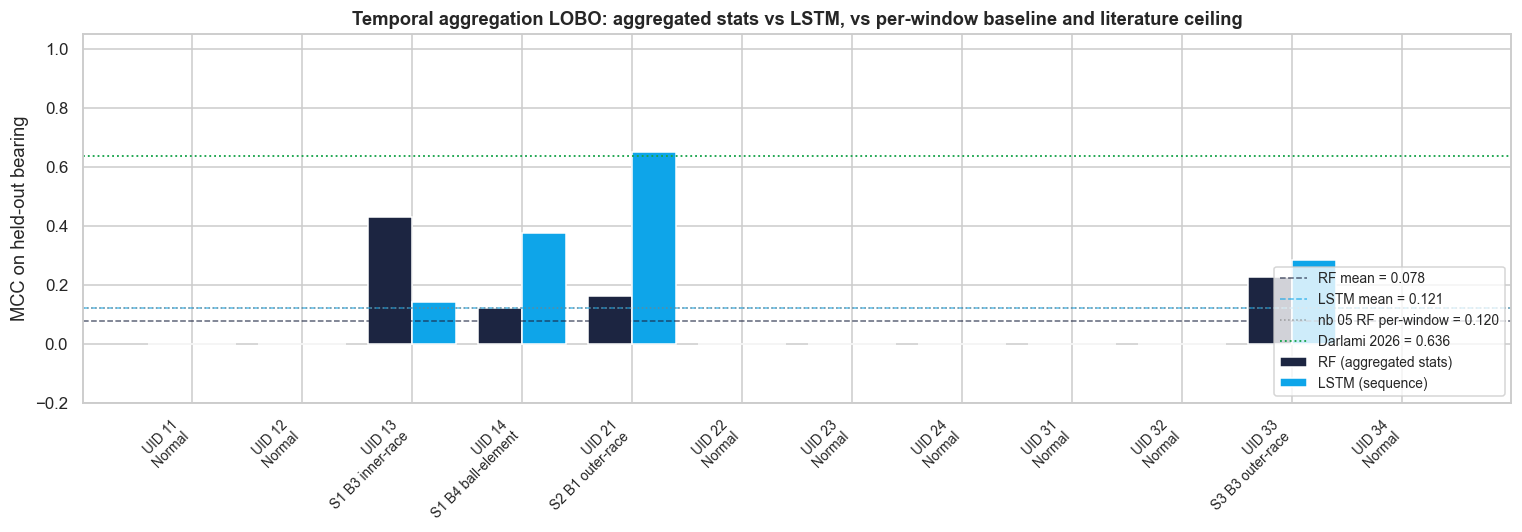

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(14, 5))
width = 0.4
x = np.arange(len(BEARING_UIDS))

ax.bar(x - width / 2, rf_agg_df["MCC"].to_numpy(), width=width, color="#1c2541", label="RF (aggregated stats)")
ax.bar(x + width / 2, lstm_df["MCC"].to_numpy(),  width=width, color="#0ea5e9", label="LSTM (sequence)")

ax.axhline(rf_agg_df["MCC"].mean(), color="#1c2541", ls="--", lw=1, alpha=0.7, label=f"RF mean = {rf_agg_df['MCC'].mean():.3f}")
ax.axhline(lstm_df["MCC"].mean(),  color="#0ea5e9", ls="--", lw=1, alpha=0.7, label=f"LSTM mean = {lstm_df['MCC'].mean():.3f}")
ax.axhline(0.120, color="grey", ls=":", lw=1, alpha=0.7, label="nb 05 RF per-window = 0.120")
ax.axhline(0.636, color="#16a34a", ls=":", lw=1.2, label="Darlami 2026 = 0.636")

ax.set_xticks(x)
ax.set_xticklabels([f"UID {u}\n{NAMES.get(u, 'Normal')}" for u in BEARING_UIDS], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("MCC on held-out bearing")
ax.set_title("Temporal aggregation LOBO: aggregated stats vs LSTM, vs per-window baseline and literature ceiling", fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.set_ylim(-0.2, 1.05)
fig.tight_layout()
fig.savefig(FIG_DIR / "13_temporal_lobo.png", dpi=130, bbox_inches="tight")
plt.show()

## 8. Discussion

Three reads on the comparison.

**1. Does aggregation help?** If the aggregated-stats Random Forest beats the per-window Random Forest, the temporal aggregation is doing useful work — within-snapshot variance and consistency carry signal that the per-window classifier discards.

**2. Does the LSTM beat the aggregated stats?** If yes, the *order* of the windows within a snapshot — not just their summary statistics — encodes additional information. If the LSTM matches the aggregated stats but doesn't beat them, the sequence ordering isn't adding much over the simpler aggregation.

**3. How far do we close the gap to Darlami 0.636?** A meaningful step toward the literature ceiling, but the remaining gap is real: Darlami's Fed-TGCN aggregates across *snapshots*, not just within a single 1-second snapshot, and adds graph structure on top. The natural extension is a hierarchical model: per-window LSTM → per-snapshot embedding → across-snapshot temporal model.

**For the article.** This notebook lets the comparison table grow from four rows (Set-2 stratified) → six rows (with LOBO per-window) → eight rows (with temporal aggregation). The honest message: matching the literature ceiling requires both *temporal aggregation* and *graph structure*, in roughly that order of impact.